# Feed-Forward Neural Network for Handwritten Digit Classification

This notebook builds a small feed-forward (fully connected) neural network with
TensorFlow/Keras to classify images of handwritten digits (0 through 9).

It uses scikit-learn's built-in `load_digits` dataset (1797 images, 8x8 pixels) instead of
the full MNIST dataset, so the notebook runs entirely offline with no download required.
The note at the end of the README explains the one-line change needed to swap in full
MNIST instead.

## 1. Load the digit images and look at a few

Each sample is an 8x8 grayscale image of a handwritten digit, with pixel values from 0 to
16. We load the images and a handful of their true labels, and display a few to see what
the model will be working with.

Images shape: (1797, 8, 8)
Labels shape: (1797,)


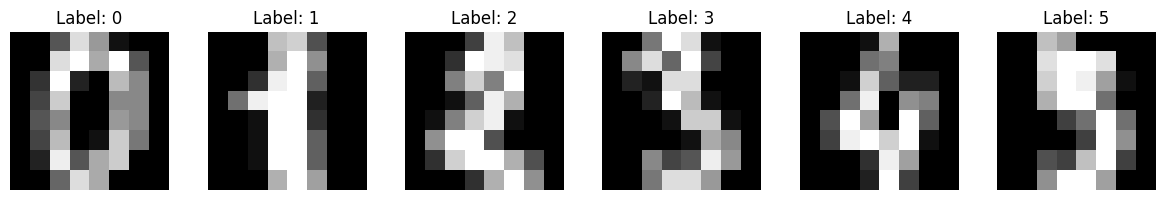

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

digits = load_digits()
images = digits.images   # shape (1797, 8, 8)
labels = digits.target   # shape (1797,)

print('Images shape:', images.shape)
print('Labels shape:', labels.shape)

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for ax, img, label in zip(axes, images[:6], labels[:6]):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Split the data and normalize pixel values

We split into train and test sets first. Then we normalize pixel values by dividing by 16,
the maximum pixel value in this dataset, so every input feature falls between 0 and 1.
Neural networks train more reliably on inputs kept in a small, consistent range, large or
uneven input scales can slow down or destabilize training.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=42
)

# Normalize to the 0-1 range (16 is the max pixel value for this dataset)
X_train = X_train / 16.0
X_test = X_test / 16.0

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Pixel value range after normalization:', X_train.min(), 'to', X_train.max())

Train shape: (1437, 8, 8)
Test shape: (360, 8, 8)
Pixel value range after normalization: 0.0 to 1.0


## 3. Build the model

The network has three layers:

- **Flatten(input_shape=(8, 8))**: turns each 8x8 image into a single 64-value vector, so
  the fully connected layers that follow can treat it as a flat list of numbers.
- **Dense(128, activation='relu')**: a fully connected hidden layer of 128 neurons. ReLU
  (Rectified Linear Unit) outputs the input directly if it is positive and 0 otherwise. It
  is simple to compute and lets the network learn non-linear patterns, without it, stacking
  layers would collapse into one big linear function no matter how many layers there were.
- **Dense(10, activation='softmax')**: the output layer, one neuron per digit class.
  Softmax converts the raw output scores into a probability distribution over the 10
  classes, so they are all positive and sum to 1, and the class with the highest
  probability is the model's prediction.

In [3]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(8, 8)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
])

model.summary()

C:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,610 (37.54 KB)

 Trainable params: 9,610 (37.54 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile the model

- **Optimizer (adam)**: an adaptive gradient descent method that adjusts the learning rate
  per parameter as training goes, a solid default that needs little tuning.
- **Loss (sparse_categorical_crossentropy)**: measures how far the predicted probability
  distribution is from the true label. "Sparse" means the labels are given as plain
  integers (0-9) rather than one-hot encoded vectors, which is more convenient here.

In [4]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

## 5. Train the model

We train for several epochs (full passes over the training data) and hold out part of the
training set as a validation split, so we can watch how the model performs on data it is
not directly training on, in addition to the training data itself, during training.

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    verbose=0,
)

print('Final training accuracy:', round(history.history['accuracy'][-1], 3))
print('Final validation accuracy:', round(history.history['val_accuracy'][-1], 3))

Final training accuracy: 0.99
Final validation accuracy: 0.948


## 6. Evaluate on the test set

The test set was never used during training or validation, so this is the best estimate of
how the model would perform on genuinely new digit images.

In [6]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

Test loss: 0.1157
Test accuracy: 0.9722


## 7. Plot training versus validation curves

Comparing training and validation accuracy/loss over the epochs is the standard way to
check for overfitting. If training accuracy keeps climbing while validation accuracy
flattens or drops (equivalently, training loss keeps falling while validation loss starts
rising), the model is starting to memorize the training data instead of learning patterns
that generalize. If both curves move together and level off close to each other, the model
is fitting well without overfitting.

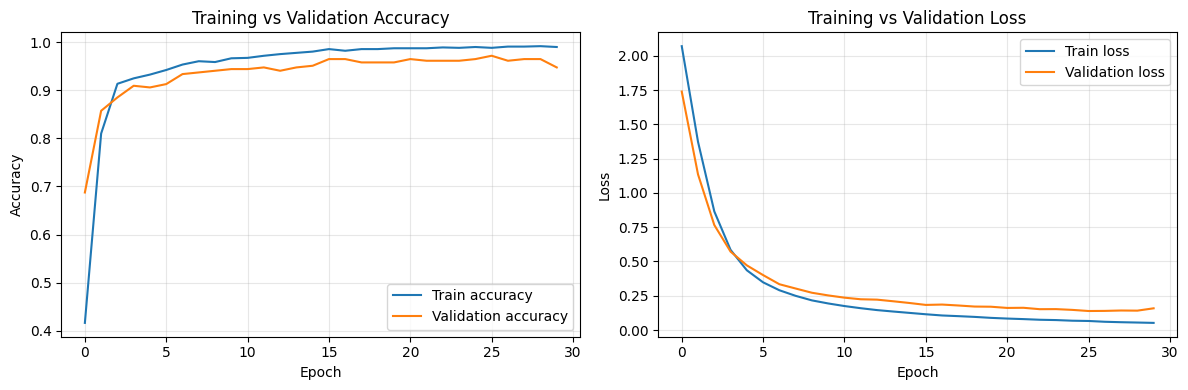

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Look at some sample predictions

Finally, we run the model on a handful of test images and compare its predicted label
against the true label, to see the model's output in a concrete, human-readable form
rather than just as summary metrics.

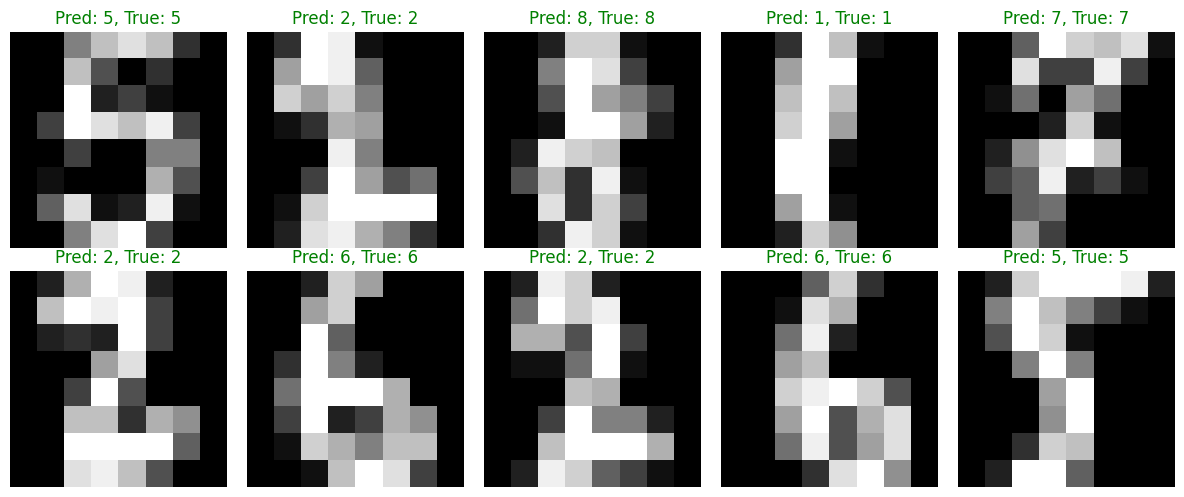

In [8]:
predictions = model.predict(X_test[:10], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, pred, true in zip(axes.ravel(), X_test[:10], predicted_labels, y_test[:10]):
    ax.imshow(img, cmap='gray')
    color = 'green' if pred == true else 'red'
    ax.set_title(f'Pred: {pred}, True: {true}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()